In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from dstapi import DstApi
from scipy import optimize

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

plt.rcParams.update({
    'axes.grid': True,
    'grid.color': 'black',
    'grid.alpha': 0.25,
    'grid.linestyle': '--'
})

plt.rcParams.update({'font.size': 14})

In [2]:
#%pip install git+https://github.com/alemartinello/dstapi

# Data Analysis Project

## 1. Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [3]:
# a. setup table
IFOR41 = DstApi('IFOR41')

# b. overview of table
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [4]:
# a. set download parameters
params = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# b. download data
gini = IFOR41.get_data(params=params)

# c. show first observations
gini.head()

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [5]:
# d. clean data

# replace missing values with NaN
I = gini['INDHOLD'] == '..'
gini.loc[I, 'INDHOLD'] = 'nan'

# convert variable types
gini['TID'] = gini['TID'].astype(int)
gini['INDHOLD'] = gini['INDHOLD'].astype(float)

# drop unnecessary variables
gini = gini.drop(columns=['ULLIG', 'KOMMUNEDK'])

# rename variables
gini = gini.rename(columns={
    'TID': 'year',
    'INDHOLD': 'gini'
})

# sort by year
gini = gini.sort_values('year').reset_index(drop=True)

gini.head()

,year,gini
0,1987,22.07
1,1988,22.06
2,1989,21.93
3,1990,22.16
4,1991,21.99


In [6]:
# e. verify data
gini.info()
gini.describe()

<class 'pandas.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    38 non-null     int64  
 1   gini    38 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 740.0 bytes


,year,gini
count,38.000000,38.000000
mean,2005.500000,25.918421
std,11.113055,2.972756
min,1987.000000,21.930000
25%,1996.250000,22.990000
50%,2005.500000,25.970000
75%,2014.750000,28.660000
max,2024.000000,30.610000


In [7]:
gini.tail()

,year,gini
33,2020,29.72
34,2021,30.28
35,2022,29.96
36,2023,30.61
37,2024,30.43


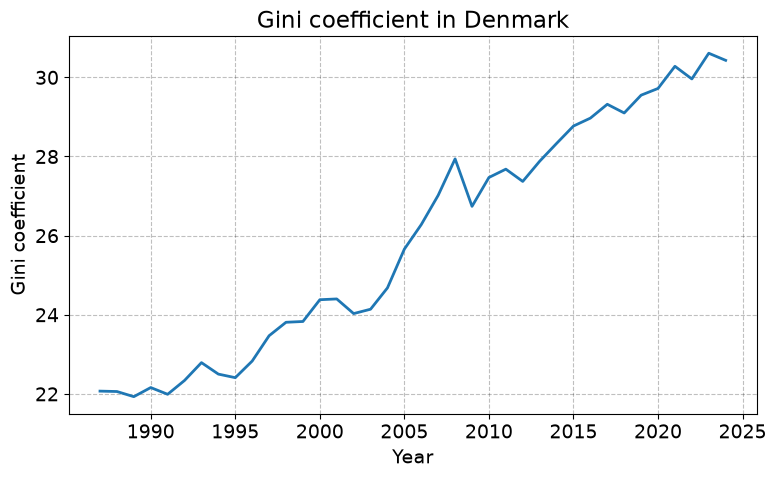

In [8]:
# f. plot Gini coefficient

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

ax.plot(gini['year'], gini['gini'], lw=2)

ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini coefficient')

fig.tight_layout()

In [9]:
# g. setup table for income deciles
IFOR32 = DstApi('IFOR32')

# h. overview of table
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
# i. set download parameters
params = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

# j. download data
deciles = IFOR32.get_data(params=params)

# k. show first observations
deciles.head()

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,First decil,All Denmark,2013,75704
1,Second decil,All Denmark,2013,140049
2,Third decil,All Denmark,2013,163582
3,Fourth decil,All Denmark,2013,185931
4,Fifth decil,All Denmark,2013,209384


In [12]:
# l. clean decile data

# a. convert variable types
deciles['TID'] = deciles['TID'].astype(int)
deciles['INDHOLD'] = deciles['INDHOLD'].astype(float)

# b. drop unnecessary variable
deciles = deciles.drop(columns=['KOMMUNEDK'])

# c. rename variables
deciles = deciles.rename(columns={
    'DECILGEN': 'decile',
    'TID': 'year',
    'INDHOLD': 'income'
})

# d. sort by year
deciles = deciles.sort_values('year').reset_index(drop=True)

# e. show first observations
deciles.head(10)

,decile,year,income
0,First decil,1987,31418.0
1,Ninth decil,1987,123582.0
2,Eigth decil,1987,110184.0
3,Seventh decil,1987,100691.0
4,Sixth decil,1987,92777.0
5,Fifth decil,1987,85361.0
6,Fourth decil,1987,77577.0
7,Third decil,1987,68786.0
8,Second decil,1987,59014.0
9,Tenth decil,1987,169598.0


In [13]:
# m. verify decile data

deciles.info()
deciles.describe()

print(deciles['decile'].unique())
print(f'Number of observations: {len(deciles)}')

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   decile  380 non-null    str    
 1   year    380 non-null    int64  
 2   income  380 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 13.3 KB
<ArrowStringArray>
[  'First decil',   'Ninth decil',   'Eigth decil', 'Seventh decil',
   'Sixth decil',   'Fifth decil',  'Fourth decil',   'Third decil',
  'Second decil',   'Tenth decil']
Length: 10, dtype: str
Number of observations: 380


In [14]:
# n. calculate top 10 percent income share

# a. calculate total income across deciles within each year
deciles['total_income'] = (
    deciles.groupby('year')['income'].transform('sum')
)

# b. calculate income share for each decile
deciles['income_share'] = (
    deciles['income'] / deciles['total_income']
)

# c. select the tenth decile
I = deciles['decile'] == 'Tenth decil'

top10 = deciles.loc[I, ['year', 'income_share']].copy()

# d. rename variable
top10 = top10.rename(columns={
    'income_share': 'top10_share'
})

# e. convert share to percent
top10['top10_share'] = 100 * top10['top10_share']

# f. sort by year
top10 = top10.sort_values('year').reset_index(drop=True)

top10.head()

,year,top10_share
0,1987,18.454866
1,1988,18.428870
2,1989,18.495170
3,1990,18.641480
4,1991,18.668346


In [15]:
# o. merge inequality measures

# a. merge Gini coefficient and top 10 percent share
inequality = pd.merge(
    gini,
    top10,
    on='year',
    how='inner'
)

# b. show first observations
inequality.head()

,year,gini,top10_share
0,1987,22.07,18.454866
1,1988,22.06,18.428870
2,1989,21.93,18.495170
3,1990,22.16,18.641480
4,1991,21.99,18.668346


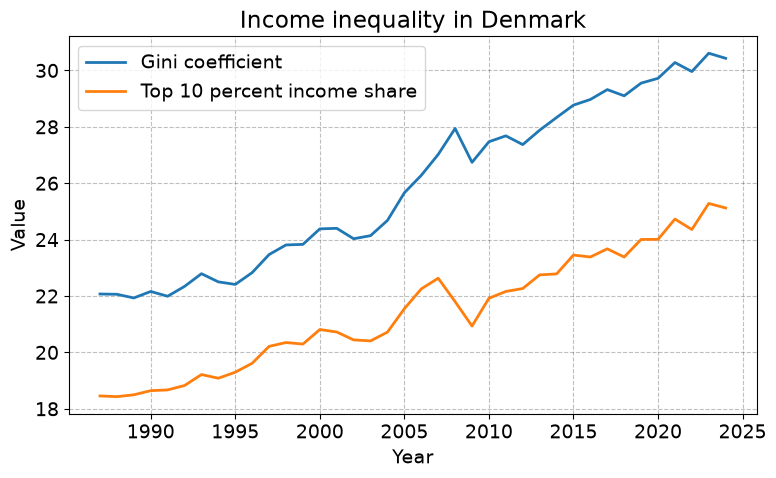

In [19]:
# p. plot inequality measures

fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(1,1,1)

# a. plot both measures
ax.plot(
    inequality['year'],
    inequality['gini'],
    lw=2,
    label='Gini coefficient'
)

ax.plot(
    inequality['year'],
    inequality['top10_share'],
    lw=2,
    label='Top 10 percent income share'
)

# b. labels
ax.set_title('Income inequality in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Value')

# c. legend
ax.legend()

fig.tight_layout()

In [17]:
# q. calculate correlation

corr = inequality['gini'].corr(
    inequality['top10_share']
)

print(f'Correlation between the two inequality measures: {corr:.3f}')

Correlation between the two inequality measures: 0.982


#### Discussion

Income inequality in Denmark has increased substantially since 1987. 
The Gini coefficient increased from approximately 22 in 1987 to above 
30 in 2024. Similarly, the income share of the richest 10 percent 
increased from approximately 18.5 percent to around 25 percent.

The two measures therefore tell a very similar story. Both indicate a 
general increase in income inequality over the period, although there 
are some temporary fluctuations. In particular, both measures decline 
around 2009 before continuing their upward trend.

The correlation between the Gini coefficient and the top 10 percent 
income share is 0.982. This indicates a very strong positive relationship 
between the two measures over time.

### 1.2 Prediction

We fit a linear and a quadratic trend to the Gini coefficient using
least squares. The models are estimated using `scipy.optimize.minimize`
and subsequently checked against `np.polyfit`.